### Black and white image colorization with OpenCV and Deep Learning

##### 1. Importing Libraries

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!wget

In [ ]:
image = cv2.imread('black_white.png')

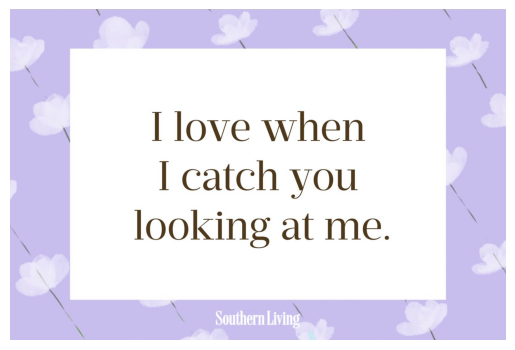

In [6]:
plt.imshow(image)
plt.axis('off')
plt.show()

In [ ]:
# Convert BGR to RGB for matplotlib display
original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
colorized_rgb = cv2.cvtColor(colorized, cv2.COLOR_BGR2RGB)

# Convert to grayscale for comparison
grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original image
axes[0].imshow(original_rgb)
axes[0].set_title("Original Image", fontsize=14, fontweight='bold')
axes[0].axis('off')

# Grayscale version
axes[1].imshow(grayscale, cmap='gray')
axes[1].set_title("Grayscale Input", fontsize=14, fontweight='bold')
axes[1].axis('off')

# Colorized result
axes[2].imshow(colorized_rgb)
axes[2].set_title("Colorized Output", fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Save the colorized image
output_path = "./colorized_result.jpg"
cv2.imwrite(output_path, colorized)
print(f"✓ Colorized image saved to {output_path}")

##### 6. Display Results

In [ ]:
# Convert BGR to LAB color space
# L channel (lightness) will be used from the original image
# AB channels will be predicted by the model
lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

# Resize image to 224x224 (required input size for the model)
l_resized = cv2.resize(l, (224, 224))

# Create blob from the L channel
# Normalize the L channel to range [0, 1]
l_blob = cv2.dnn.blobFromImage(l_resized, 1.0/255, (224, 224), 50)

# Set input to the network
net.setInput(l_blob)

# Forward pass - get AB channels predictions
ab = net.forward()[0, :, :, :]  # Get the output
ab = cv2.resize(ab, (original_shape[1], original_shape[0]))

# Combine the original L channel with predicted AB channels
l = l.astype("float32") / 255.0
a = ab[0] * 110.0
b = ab[1] * 110.0

# Convert back to BGR
lab_output = np.dstack([l, a, b])
colorized = cv2.cvtColor(lab_output, cv2.COLOR_LAB2BGR)
colorized = np.clip(colorized * 255, 0, 255).astype("uint8")

print("✓ Image colorization complete!")